# 01 — Explore Scenario

Declarative schedule → 1 Hz household aggregate + per-appliance ground truth. Visualise a single test-day slice.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
from aerogrid.sim.scenario import load_scenario_mains, load_scenario_appliance
from aerogrid.config import SCENARIO_DIR, SCENARIO_TEST_START
from datetime import timedelta

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

mains = load_scenario_mains()
day = mains[(mains['timestamp'] >= SCENARIO_TEST_START) & (mains['timestamp'] < SCENARIO_TEST_START + timedelta(days=10))]
print(f'test-day-1 rows: {len(day):,}')

test-day-1 rows: 864,000


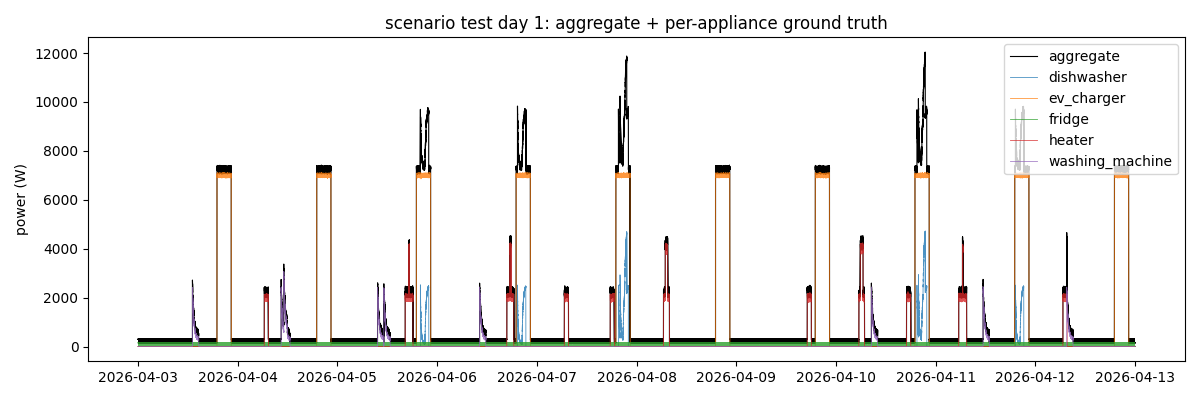

In [2]:
# Aggregate + per-appliance overlay for one test day.
appliance_names = sorted(
    p.stem.removesuffix('_1hz')
    for p in SCENARIO_DIR.glob('*_1hz.parquet')
    if p.stem != 'mains_1hz'
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(day['timestamp'], day['power_w'], lw=0.8, color='black', label='aggregate')
for name in appliance_names:
    df = load_scenario_appliance(name)
    slot = df[(df['timestamp'] >= SCENARIO_TEST_START) & (df['timestamp'] < SCENARIO_TEST_START + timedelta(days=10))]
    ax.plot(slot['timestamp'], slot['power_w'], lw=0.6, alpha=0.8, label=name)

ax.set_ylabel('power (W)')
ax.set_title('scenario test day 1: aggregate + per-appliance ground truth')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [3]:
# Onset table for the full test window.
from aerogrid.behavioral_predictor import load_onsets
onsets = load_onsets()
test_onsets = onsets[onsets['split'] == 'test']
display(test_onsets.head(20))
print(f'test onsets: {len(test_onsets)} total')

,timestamp,appliance,split
349,2026-04-03 13:06:00+00:00,washing_machine,test
350,2026-04-03 19:00:00+00:00,ev_charger,test
351,2026-04-04 06:23:00+00:00,heater,test
352,2026-04-04 10:27:00+00:00,washing_machine,test
353,2026-04-04 11:05:00+00:00,washing_machine,test
354,2026-04-04 19:00:00+00:00,ev_charger,test
355,2026-04-05 09:39:00+00:00,washing_machine,test
356,2026-04-05 11:10:00+00:00,washing_machine,test
357,2026-04-05 16:18:00+00:00,heater,test
358,2026-04-05 17:10:00+00:00,heater,test


test onsets: 69 total
